In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve
import joblib
from sklearn.preprocessing import StandardScaler

Definicion y preparación de los dataframe

In [2]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P","p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates','Lb_ETA','Jpsi_ETA', 'p_ETA','pim_ETA']

In [3]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [4]:
#Preselection data.
signal_data = pd.read_pickle('data24_armenteros.pkl')
adding_data = pd.read_pickle('data24_armenteros_add.pkl')
adding_data_2 = pd.read_pickle('data24_training.pkl')
adding_event_num = adding_data_2['EVENTNUMBER']
signal_data_2 = pd.concat([signal_data,adding_data],axis='columns')
signal_data = pd.concat([signal_data_2,adding_event_num],axis='columns')
#Creates a new variables like the Cos()...
sum_CHI2 = signal_data['Lb_CHI2']+signal_data['L_CHI2']+signal_data['Jpsi_CHI2']
angle = np.arccos((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_angle = ((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_xi_L = ((signal_data['p_PX']*signal_data['L_PX']+signal_data['p_PY']*signal_data['L_PY']+signal_data['p_PZ']*signal_data['L_PZ'])/(signal_data['p_P']*signal_data['L_P']))
cos_xi_Lb = ((signal_data['p_PX']*signal_data['Lb_PX']+signal_data['p_PY']*signal_data['Lb_PY']+signal_data['p_PZ']*signal_data['Lb_PZ'])/(signal_data['p_P']*signal_data['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
signal_data['SUMCHI2'] = sum_CHI2
signal_data['Theta_P'] = angle
signal_data['Cos_theta_P'] = cos_angle
signal_data['Cos_xi_LP'] = cos_xi_L
signal_data['Cos_xi_LbP'] = cos_xi_Lb
signal_data['xi_LP'] = xi_LP
signal_data['xi_LbP'] = xi_LbP

signal_data['SUMCHI2'] = signal_data['L_CHI2'] + signal_data['Lb_CHI2'] + signal_data['Jpsi_CHI2']
data24_selected_chi2  = signal_data[signal_data.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==signal_data['SUMCHI2']].drop_duplicates('EVENTNUMBER')
signal_data  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

signal_data


/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,EVENTNUMBER,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1077.975830,5846.956055,2974.502686,54863.386719,1776.397949,4.123077,0.005935,0.002314,0.997817,1.207904,...,-215.8711,7895.8999,20908651765,1.332619,0.140961,0.990081,0.999991,0.999902,0.004257,0.014029
1,1077.976562,5313.719238,3112.583496,58726.832031,1343.211792,4.470844,0.122067,0.009861,0.997888,1.222700,...,505.1554,7826.0996,9108814155,1.834390,0.127805,0.991844,0.999985,0.999979,0.005426,0.006496
2,1078.187256,6402.193359,3093.716309,18753.294922,2738.893555,2.611505,0.071255,0.009010,0.984698,1.317595,...,-605.9817,7826.0996,52766863075,8.643069,0.336862,0.943797,0.999327,0.999409,0.036701,0.034373
3,1078.331421,5060.589355,3078.505615,36252.464844,492.338257,4.992107,1.107087,0.028151,0.996496,1.103896,...,-23.0286,7826.0996,60459510981,24.885163,0.171750,0.985287,0.999998,0.999966,0.002072,0.008250
4,1078.344971,5300.834473,2953.872803,26179.085938,1636.410034,3.464616,1.147581,0.034740,0.992858,1.206773,...,-189.1307,7895.8999,14255646708,5.839044,0.227141,0.974314,1.000000,0.999871,0.000000,0.016058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385519,1499.999146,5856.114746,3094.393799,40905.226562,5709.117676,2.657336,0.828369,0.017847,0.999323,0.916992,...,223.2184,7826.0991,9458830900,22.081788,0.161229,0.987031,0.999392,0.999959,0.034860,0.009076
2385520,1499.999146,5465.837891,3116.906006,68869.664062,1651.937012,4.423246,0.240755,0.012574,0.999810,1.170818,...,-302.4525,7895.8994,10458796493,37.424356,0.094939,0.995497,0.999515,0.999125,0.031148,0.041827
2385521,1499.999268,5057.749512,3105.656494,37938.269531,3193.528564,3.166201,2.272352,0.042266,0.986553,1.228708,...,225.9496,7826.0991,10398074588,23.769515,0.165611,0.986318,0.999625,0.994184,0.027388,0.107904
2385523,1499.999756,6493.334473,3065.772461,27737.134766,2734.924072,3.007334,0.421790,0.024650,0.999892,1.357072,...,-422.2669,7826.0991,29213226058,26.433014,0.223562,0.975114,0.999879,0.999713,0.015564,0.023974


In [5]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'EVENTNUMBER'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")



mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_background = mc_background_merge.query(preselection_cut_mc)


#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LP
mc_signal['xi_LbP'] = xi_LbP

data24_selected_chi2  = mc_signal[mc_signal.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_signal  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()


#Creates a new variables like the Cos()...
sum_CHI2 = mc_background['Lb_CHI2']+mc_background['L_CHI2']+mc_background['Jpsi_CHI2']
angle = np.arccos((mc_background['mum_PX']*mc_background['mup_PX']+mc_background['mum_PY']*mc_background['mup_PY']+mc_background['mum_PZ']*mc_background['mup_PZ'])/(mc_background['mum_P']*mc_background['mup_P']))
cos_angle = ((mc_background['mum_PX']*mc_background['mup_PX']+mc_background['mum_PY']*mc_background['mup_PY']+mc_background['mum_PZ']*mc_background['mup_PZ'])/(mc_background['mum_P']*mc_background['mup_P']))
cos_xi_L = ((mc_background['p_PX']*mc_background['L_PX']+mc_background['p_PY']*mc_background['L_PY']+mc_background['p_PZ']*mc_background['L_PZ'])/(mc_background['p_P']*mc_background['L_P']))
cos_xi_Lb = ((mc_background['p_PX']*mc_background['Lb_PX']+mc_background['p_PY']*mc_background['Lb_PY']+mc_background['p_PZ']*mc_background['Lb_PZ'])/(mc_background['p_P']*mc_background['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_background['SUMCHI2'] = sum_CHI2
mc_background['Theta_P'] = angle
mc_background['Cos_theta_P'] = cos_angle
mc_background['Cos_xi_LP'] = cos_xi_L
mc_background['Cos_xi_LbP'] = cos_xi_Lb
mc_background['xi_LP'] = xi_LP
mc_background['xi_LbP'] =  xi_LbP

data24_selected_chi2  = mc_background[mc_background.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_background['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_background  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()



/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_15194/2018369150.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_15194/2018369150.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_15194/2018369150.py:41: PerformanceWarning: DataFrame is highly 

In [6]:

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")
mc_signal_background = mc_signal_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal_background['Lb_CHI2']+mc_signal_background['L_CHI2']+mc_signal_background['Jpsi_CHI2']
angle = np.arccos((mc_signal_background['mum_PX']*mc_signal_background['mup_PX']+mc_signal_background['mum_PY']*mc_signal_background['mup_PY']+mc_signal_background['mum_PZ']*mc_signal_background['mup_PZ'])/(mc_signal_background['mum_P']*mc_signal_background['mup_P']))
cos_angle = ((mc_signal_background['mum_PX']*mc_signal_background['mup_PX']+mc_signal_background['mum_PY']*mc_signal_background['mup_PY']+mc_signal_background['mum_PZ']*mc_signal_background['mup_PZ'])/(mc_signal_background['mum_P']*mc_signal_background['mup_P']))
cos_xi_L = ((mc_signal_background['p_PX']*mc_signal_background['L_PX']+mc_signal_background['p_PY']*mc_signal_background['L_PY']+mc_signal_background['p_PZ']*mc_signal_background['L_PZ'])/(mc_signal_background['p_P']*mc_signal_background['L_P']))
cos_xi_Lb = ((mc_signal_background['p_PX']*mc_signal_background['Lb_PX']+mc_signal_background['p_PY']*mc_signal_background['Lb_PY']+mc_signal_background['p_PZ']*mc_signal_background['Lb_PZ'])/(mc_signal_background['p_P']*mc_signal_background['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal_background['SUMCHI2'] = sum_CHI2
mc_signal_background['Theta_P'] = angle
mc_signal_background['Cos_theta_P'] = cos_angle
mc_signal_background['Cos_xi_LP'] = cos_xi_L
mc_signal_background['Cos_xi_LbP'] = cos_xi_Lb
mc_signal_background['xi_LP'] = xi_LP
mc_signal_background['xi_LbP'] = xi_LbP

data24_selected_chi2  = mc_signal_background[mc_signal_background.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal_background['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_signal_background  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_15194/1710463827.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal_background['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_15194/1710463827.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_background['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_15194/1710463827.py:15: PerformanceWarning

Representación de las variables de entrenamiento 

In [7]:
training_keys = ['Jpsi_PT',
 'L_END_VRHO',
 'L_BPVDIRA',
 'L_BPVIP',
 'L_BPVIPCHI2',
 'Lb_BPVDIRA',
 'Lb_BPVIP',
 'Lb_BPVVDRHO',
 'Lb_MAXDOCA',
 'Lb_P',
 'Lb_PT',
 'Lb_CHI2',
 'p_PID_P',
 'p_MINIP',
 'mup_PID_MU',
 'L_PT',
 'Jpsi_MAXDOCA',
 'Lb_MINIPCHI2',
 'L_P',
 'Jpsi_BPVDIRA',
 'L_CHI2',
 'Lb_ETA',
 'L_END_VZ',
 'L_END_VX',
 'L_END_VY',
 'Jpsi_ETA',
 'p_P',
 'p_PT',
 'p_ETA',
 'p_GHOSTPROB',
 'pim_P',
 'pim_PT',
 'pim_ETA',
 'pim_GHOSTPROB',
 'SUMCHI2',
 'xi_LbP',
 'xi_LP']

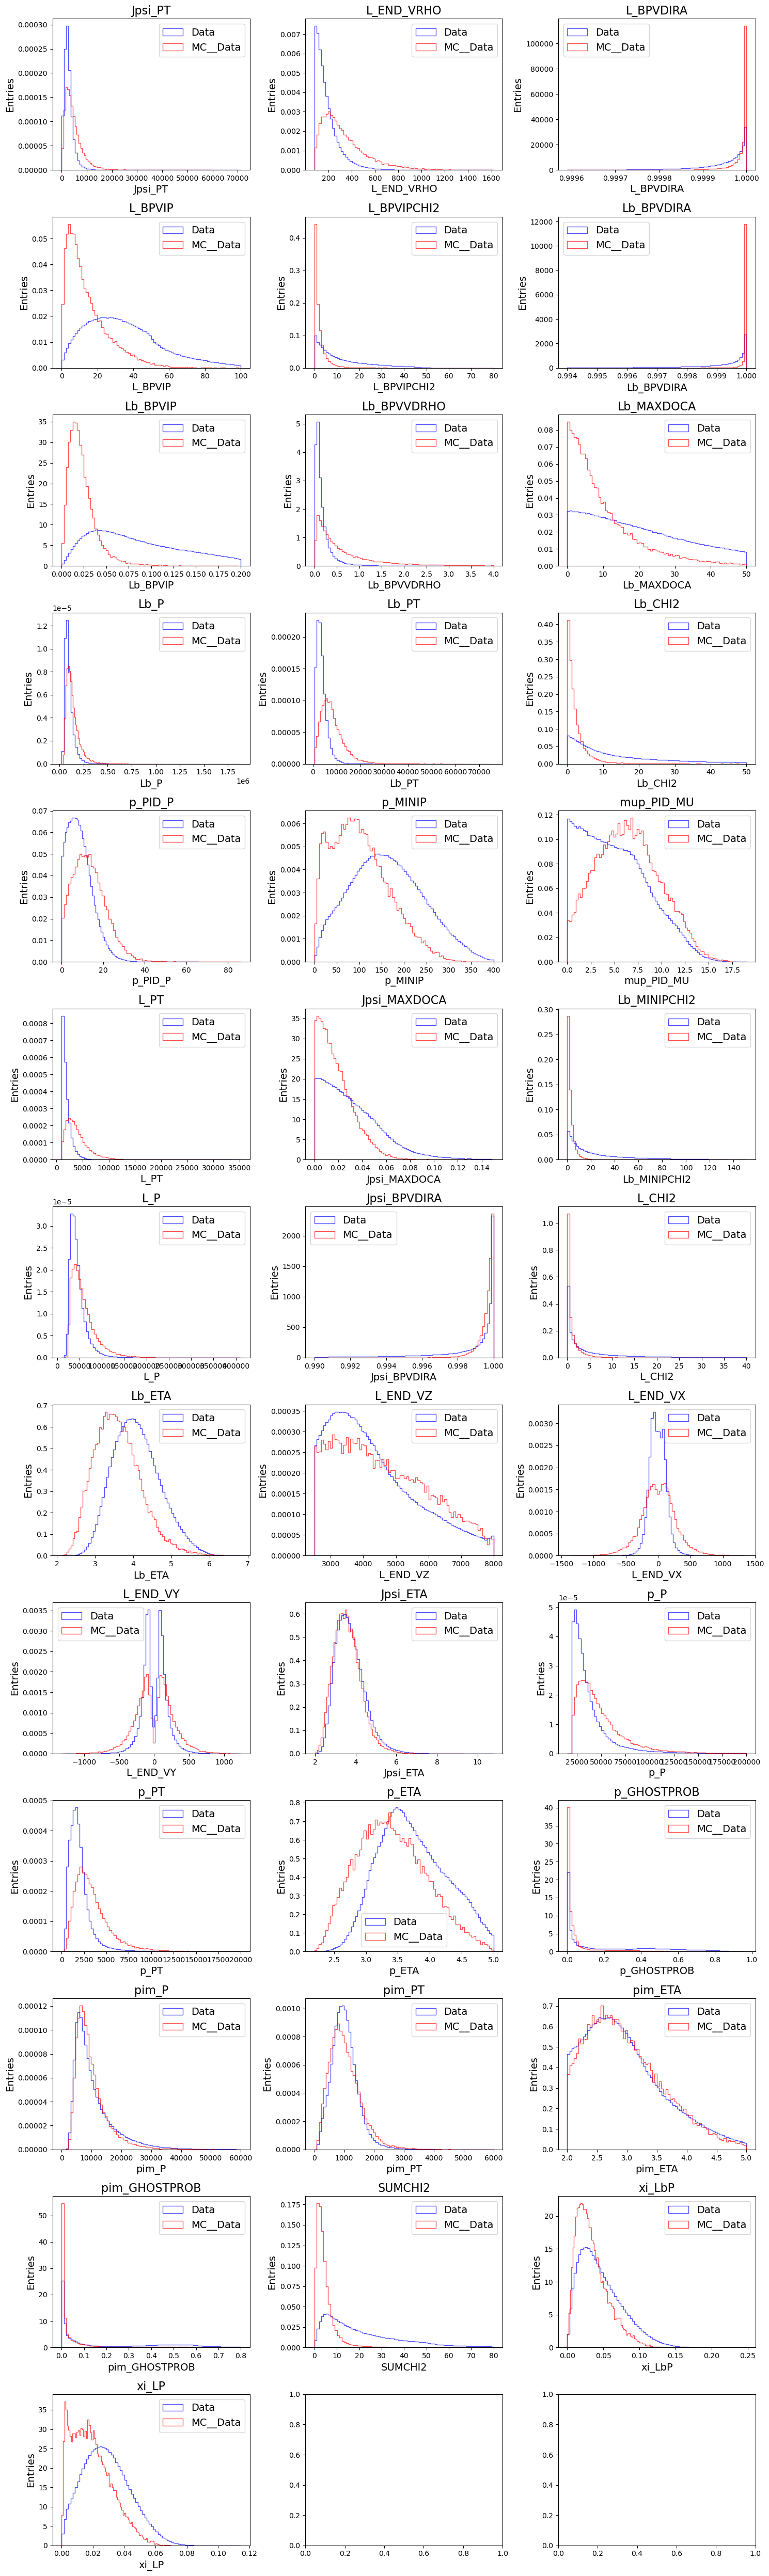

In [8]:
num_bins = 80

special_keys = ['L_BPVDIRA','L_BPVIPCHI2','Lb_BPVDIRA','Lb_BPVVDRHO','Jpsi_BPVDIRA','L_CHI2','p_P','p_PT','pim_P','pim_PT','pim_GHOSTPROB','SUMCHI2']

lin_bins = {
"L_BPVDIRA" : np.logspace(np.log10(0.99959),np.log10(1),80), 
'L_BPVIPCHI2': np.linspace(0,80,80),
'Lb_BPVDIRA': np.linspace(0.994,1,80),
'Lb_BPVVDRHO': np.linspace(0,4,80),
'Jpsi_BPVDIRA': np.linspace(0.99,1,80),
'L_CHI2':np.linspace(0,40,80),
'p_P':np.linspace(15000,200000,80),
'p_PT':np.linspace(0,20000,80),
'pim_P':np.linspace(0,60000,80),
'pim_PT':np.linspace(0,6000,80),
'pim_GHOSTPROB':np.linspace(0,0.8,80),
'SUMCHI2':np.linspace(0,80,80)
}

# Configuración de la figura y ejes
fig, axes = plt.subplots(nrows=13, ncols=3, figsize=(15, 50))

# Iterar sobre las variables y graficar un histograma para cada una
for i, variable in enumerate(training_keys):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    #ax.hist(signal_data_cut.query("(totCandidates ==1) & (prob > 0.9) & (Lb_P < 400000) & (Lb_PT < 30000) & (Lb_BPVIP < 0.2) & (Lb_BPVVDRHO < 4) & (Lb_CHI2 < 25) & (Lb_MAXDOCA < 50) & (L_BPVIP < 100) & (L_END_VRHO < 1200) & (L_MASS < 3000) & (p_MINIP < 350) & (p_PID_P < 60 ) & (p_PID_P > -30) & (p_P < 200000) & (p_PT < 14000) & (pim_P < 50000) & (pim_PT < 4000)& (totCandidates < 700)")[variable], bins=num_bins, label = 'totCandidates =1',  color='skyblue',alpha=0.7, density=True)
    if variable in special_keys:
        ax.hist(signal_data[variable], bins=lin_bins[variable], label = 'Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal[variable], bins=lin_bins[variable], color='red', label = 'MC__Data', histtype='step',alpha=0.7, density=True)

    else:
        ax.hist(signal_data[variable], bins=num_bins, label = 'Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal[variable], bins=num_bins, color='red', label = 'MC__Data', histtype='step',alpha=0.7, density=True)
    
    ax.set_xlabel(variable, fontsize= 14)
    ax.set_ylabel('Entries', fontsize= 14)
    ax.set_title(variable, fontsize= 16)
    ax.legend(fontsize= 14)

plt.tight_layout()

plt.show()

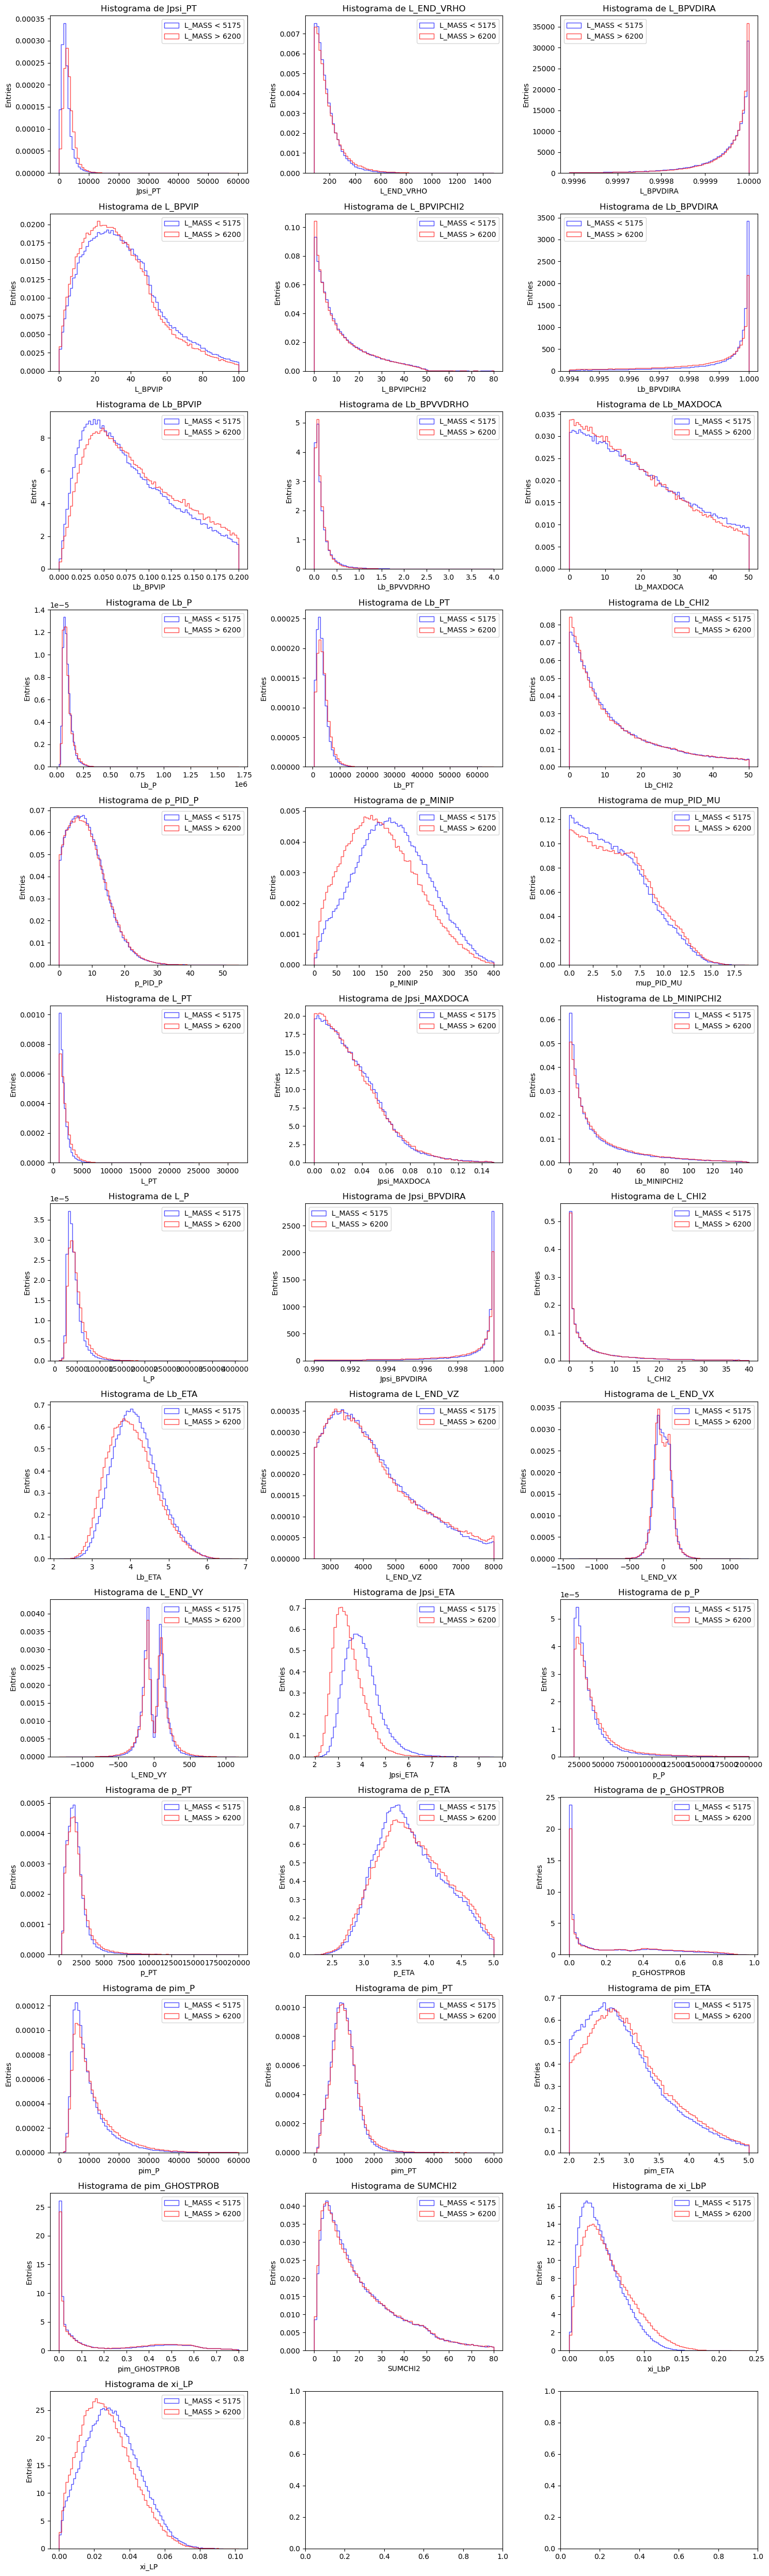

In [9]:
num_bins = 80

special_keys = ['L_BPVDIRA','L_BPVIPCHI2','Lb_BPVDIRA','Lb_BPVVDRHO','Jpsi_BPVDIRA','L_CHI2','p_P','p_PT','pim_P','pim_PT','pim_GHOSTPROB','SUMCHI2']

lin_bins = {
"L_BPVDIRA" : np.logspace(np.log10(0.99959),np.log10(1),80), 
'L_BPVIPCHI2': np.linspace(0,80,80),
'Lb_BPVDIRA': np.linspace(0.994,1,80),
'Lb_BPVVDRHO': np.linspace(0,4,80),
'Jpsi_BPVDIRA': np.linspace(0.99,1,80),
'L_CHI2':np.linspace(0,40,80),
'p_P':np.linspace(15000,200000,80),
'p_PT':np.linspace(0,20000,80),
'pim_P':np.linspace(0,60000,80),
'pim_PT':np.linspace(0,6000,80),
'pim_GHOSTPROB':np.linspace(0,0.8,80),
'SUMCHI2':np.linspace(0,80,80)
}

lower_side_band = ('Lb_MASS < 5175')
upper_side_band = ('Lb_MASS > 6200')

# Configuración de la figura y ejes
fig, axes = plt.subplots(nrows=13, ncols=3, figsize=(15, 50))

# Iterar sobre las variables y graficar un histograma para cada una
for i, variable in enumerate(training_keys):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    #ax.hist(signal_data_cut.query("(totCandidates ==1) & (prob > 0.9) & (Lb_P < 400000) & (Lb_PT < 30000) & (Lb_BPVIP < 0.2) & (Lb_BPVVDRHO < 4) & (Lb_CHI2 < 25) & (Lb_MAXDOCA < 50) & (L_BPVIP < 100) & (L_END_VRHO < 1200) & (L_MASS < 3000) & (p_MINIP < 350) & (p_PID_P < 60 ) & (p_PID_P > -30) & (p_P < 200000) & (p_PT < 14000) & (pim_P < 50000) & (pim_PT < 4000)& (totCandidates < 700)")[variable], bins=num_bins, label = 'totCandidates =1',  color='skyblue',alpha=0.7, density=True)
    if variable in special_keys:
        ax.hist(signal_data.query(lower_side_band)[variable], bins=lin_bins[variable], label = 'L_MASS < 5175',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(signal_data.query(upper_side_band)[variable], bins=lin_bins[variable], label = 'L_MASS > 6200',  color='red',alpha=0.7, histtype='step', density=True)

        # ax.hist(mc_signal.query(lower_side_band)[variable], bins=lin_bins[variable], color='red', label = 'L_MASS < 5175', histtype='step',alpha=0.7, density=True)
        # ax.hist(mc_signal.query(upper_side_band)[variable], bins=lin_bins[variable], color='orange', label = 'L_MASS > 6200', histtype='step',alpha=0.7, density=True)

    else:
        ax.hist(signal_data.query(lower_side_band)[variable], bins=num_bins, label = 'L_MASS < 5175',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(signal_data.query(upper_side_band)[variable], bins=num_bins, label = 'L_MASS > 6200',  color='red',alpha=0.7, histtype='step', density=True)

        # ax.hist(mc_signal.query(lower_side_band)[variable], bins=num_bins, color='red', label = 'L_MASS < 5175', histtype='step',alpha=0.7, density=True)
        # ax.hist(mc_signal.query(upper_side_band)[variable], bins=num_bins, color='orange', label = 'L_MASS > 6200', histtype='step',alpha=0.7, density=True)
    
    ax.set_xlabel(variable)
    ax.set_ylabel('Entries')
    ax.set_title('Histograma de {}'.format(variable))
    ax.legend()

plt.tight_layout()

plt.show()

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Definición de datos de ejemplo
num_bins = 80
special_keys = ['L_BPVDIRA','L_BPVIPCHI2','Lb_BPVDIRA','Lb_BPVVDRHO','Jpsi_BPVDIRA','L_CHI2','p_P','p_PT','pim_P','pim_PT','pim_GHOSTPROB','SUMCHI2']
lin_bins = {
    "L_BPVDIRA" : np.logspace(np.log10(0.99959), np.log10(1), 80), 
    'L_BPVIPCHI2': np.linspace(0, 80, 80),
    'Lb_BPVDIRA': np.linspace(0.994, 1, 80),
    'Lb_BPVVDRHO': np.linspace(0, 4, 80),
    'Jpsi_BPVDIRA': np.linspace(0.99, 1, 80),
    'L_CHI2': np.linspace(0, 40, 80),
    'p_P': np.linspace(15000, 200000, 80),
    'p_PT': np.linspace(0, 20000, 80),
    'pim_P': np.linspace(0, 60000, 80),
    'pim_PT': np.linspace(0, 6000, 80),
    'pim_GHOSTPROB': np.linspace(0, 0.8, 80),
    'SUMCHI2': np.linspace(0, 80, 80)
}
# Diccionario de unidades
units = {
    'Jpsi_PT': '[MeV/c]',
    'L_END_VRHO': '[mm]',
    'L_BPVDIRA': '',
    'L_BPVIP': '[mm]',
    'L_BPVIPCHI2': '',
    'Lb_BPVDIRA': '',
    'Lb_BPVIP': '[mm]',
    'Lb_BPVVDRHO': '[mrad]',
    'Lb_MAXDOCA': '[mm]',
    'Lb_P': '[MeV/c]',
    'Lb_PT': '[MeV/c]',
    'Lb_CHI2': '',
    'p_PID_P': '',
    'p_MINIP': '[mm]',
    'mup_PID_MU': '',
    'L_PT': '[MeV/c]',
    'Jpsi_MAXDOCA': '[mm]',
    'Lb_MINIPCHI2': '',
    'L_P': '[MeV/c]',
    'Jpsi_BPVDIRA': '',
    'L_CHI2': '',
    'Lb_ETA': '',
    'L_END_VZ': '[mm]',
    'L_END_VX': '[mm]',
    'L_END_VY': '[mm]',
    'Jpsi_ETA': '',
    'p_P': '[MeV/c]',
    'p_PT': '[MeV/c]',
    'p_ETA': '',
    'p_GHOSTPROB': '',
    'pim_P': '[MeV/c]',
    'pim_PT': '[MeV/c]',
    'pim_ETA': '',
    'pim_GHOSTPROB': '',
    'SUMCHI2': '',
    'xi_LbP': '[mrad]',
    'xi_LP': '[mrad]'
}


# Ajustes de tamaño de fuente
label_fontsize = 19
title_fontsize = 21
tick_fontsize = 16


# Crear directorio para guardar las imágenes
output_dir = 'output_histograms'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Iterar sobre las variables y graficar un histograma para cada una
for i, variable in enumerate(training_keys):
    fig, ax = plt.subplots(figsize=(8, 6))  # Crear una nueva figura para cada variable

    if variable in special_keys:
        ax.hist(signal_data[variable], bins=lin_bins[variable], label = '2024 Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal[variable], bins=lin_bins[variable], color='red', label = 'MC Signal', histtype='step',alpha=0.7, density=True)

    else:
        ax.hist(signal_data[variable], bins=num_bins, label = '2024 Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal[variable], bins=num_bins, color='red', label = 'MC Signal', histtype='step',alpha=0.7, density=True)
    
    unit = units.get(variable, '')  # Obtener la unidad correspondiente a la variable
    ax.set_xlabel(f'{variable} {unit}', fontsize=label_fontsize, loc='right')
    ax.set_ylabel('Entries', fontsize= label_fontsize)
    ax.set_title(variable, fontsize= title_fontsize)
    ax.legend(fontsize= label_fontsize)
    
    # Ajustar el tamaño de las etiquetas de los ticks
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    # Guardar la figura como archivo PNG en el directorio de salida
    fig.savefig(os.path.join(output_dir, 'histogram_{}.png'.format(variable)))
    
    # Cerrar la figura para liberar memoria
    plt.close(fig)


In [11]:
len(training_keys)

37

Aplicación de la BDT

In [12]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(mc_signal)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_signal['prob1'] = signal_MVA_probs

[[6.97183951e-03 9.93028160e-01]
 [2.15075988e-04 9.99784924e-01]
 [2.64916874e-02 9.73508313e-01]
 ...
 [8.55744344e-02 9.14425566e-01]
 [2.82014880e-04 9.99717985e-01]
 [1.10311341e-02 9.88968866e-01]]


Aplicación de la neural network

In [13]:
from sklearn.preprocessing import StandardScaler

mlp = joblib.load('neural_network.pkl')

nerual_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_MASS']

data24_selected_nan= mc_signal.dropna()

to_drop = [x for x in data24_selected_nan.columns if x not in nerual_keys ]
data24_selected = data24_selected_nan.drop(columns= to_drop, inplace=True)

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.99

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan[high_confidence_indices]

neural_data_mc = high_confidence_data

/tmp/javeser/ipykernel_15194/3196026790.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data24_selected = data24_selected_nan.drop(columns= to_drop, inplace=True)


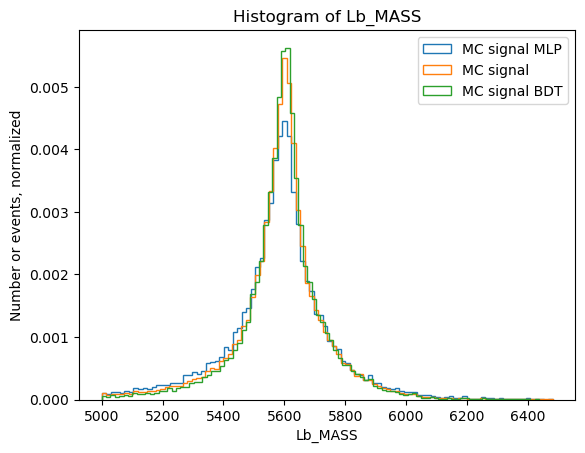

In [14]:

density = True
bins =100
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc['Lb_MASS'], bins=bins, histtype='step', label='MC signal MLP', density= density);
plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal');
plt.hist(mc_signal.query('(prob1 > 0.99)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ 'Lb_MASS')

plt.legend()

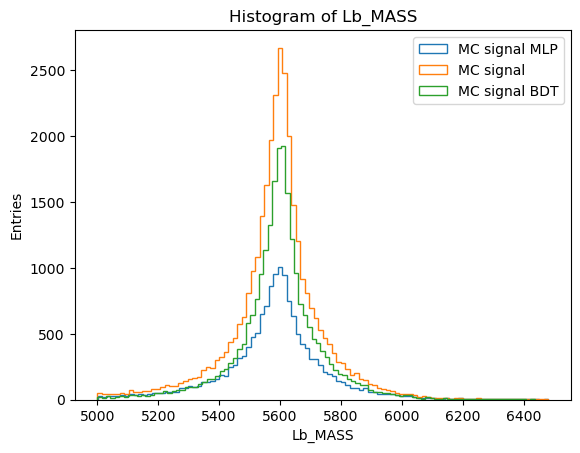

In [15]:

density = False
bins =100
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc['Lb_MASS'], bins=bins, histtype='step', label='MC signal MLP', density= density);
plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal');
plt.hist(mc_signal.query('(prob1 > 0.99)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS')

plt.legend()

Aplicar BDT y MLP para el fondo BKG

In [16]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(mc_background)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_background['prob1'] = signal_MVA_probs

[[9.99411719e-01 5.88280586e-04]
 [9.99370776e-01 6.29224165e-04]
 [8.90723772e-01 1.09276228e-01]
 ...
 [9.64073615e-01 3.59263846e-02]
 [9.99979170e-01 2.08296309e-05]
 [9.87317614e-01 1.26823856e-02]]


In [17]:
from sklearn.preprocessing import StandardScaler

mlp = joblib.load('neural_network.pkl')

nerual_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_MASS']

data24_selected_nan= mc_background.dropna()

to_drop = [x for x in data24_selected_nan.columns if x not in nerual_keys ]
data24_selected = data24_selected_nan.drop(columns= to_drop, inplace=True)

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.99

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan[high_confidence_indices]

neural_data_mc_bkg = high_confidence_data

/tmp/javeser/ipykernel_15194/3958712358.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data24_selected = data24_selected_nan.drop(columns= to_drop, inplace=True)


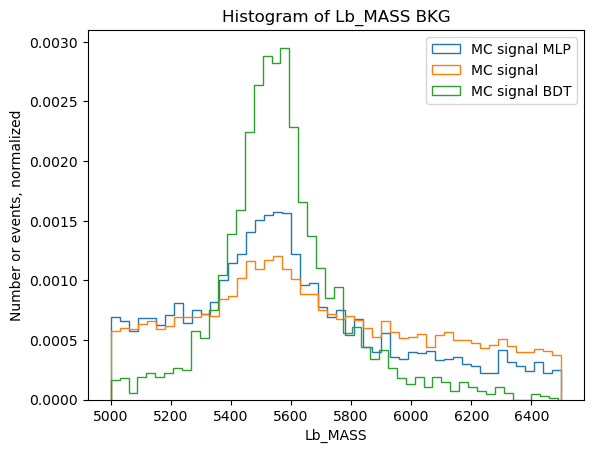

In [18]:

density = True
bins =50
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg['Lb_MASS'], bins=bins, histtype='step', label='MC signal MLP', density= density);
plt.hist(mc_background['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal');
plt.hist(mc_background.query('(prob1 > 0.99)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

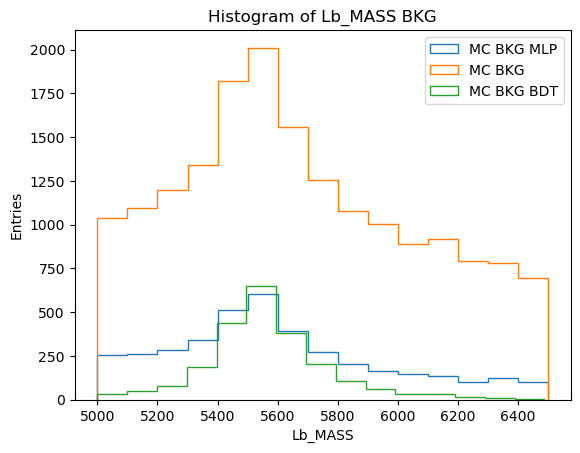

In [19]:

density = False
bins =15
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg['Lb_MASS'], bins=bins, histtype='step', label='MC BKG MLP', density= density);
plt.hist(mc_background['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG');
plt.hist(mc_background.query('(prob1 > 0.99)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

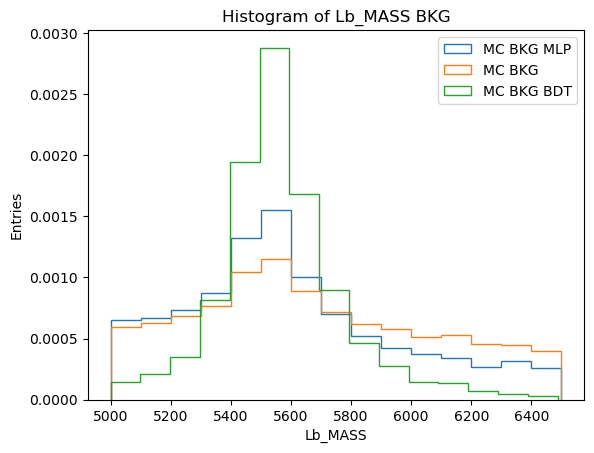

In [20]:

density = True
bins =15
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg['Lb_MASS'], bins=bins, histtype='step', label='MC BKG MLP', density= density);
plt.hist(mc_background['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG');
plt.hist(mc_background.query('(prob1 > 0.99)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

Estudio del Background shape 

In [21]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_background['Lb_BKGCAT'].value_counts(normalize='True')*100
print(conteo)

Lb_BKGCAT
100    49.553520
110    17.990841
60     16.731540
50     13.119634
40      1.642816
70      0.847167
30      0.097310
80      0.017172
Name: proportion, dtype: float64


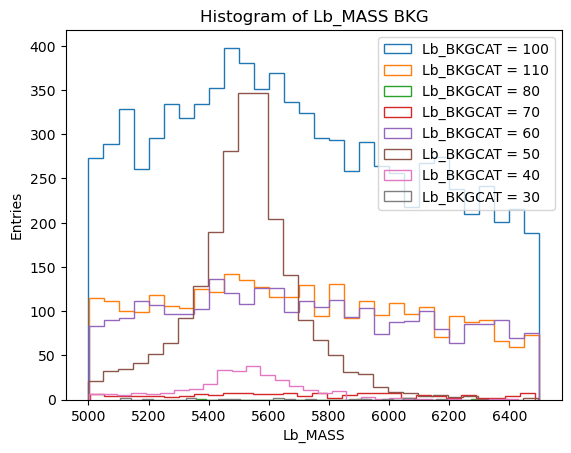

In [22]:
density = False
bins =30
caracteristica = 'Lb_MASS'


plt.hist(mc_background.query('(Lb_BKGCAT ==100)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 100');
plt.hist(mc_background.query('(Lb_BKGCAT ==110)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 110');
plt.hist(mc_background.query('(Lb_BKGCAT ==80)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 80');
plt.hist(mc_background.query('(Lb_BKGCAT ==70)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 70');
plt.hist(mc_background.query('(Lb_BKGCAT ==60)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 60');
plt.hist(mc_background.query('(Lb_BKGCAT ==50)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 50');
plt.hist(mc_background.query('(Lb_BKGCAT ==40)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 40');
plt.hist(mc_background.query('(Lb_BKGCAT ==30)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT = 30');
plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

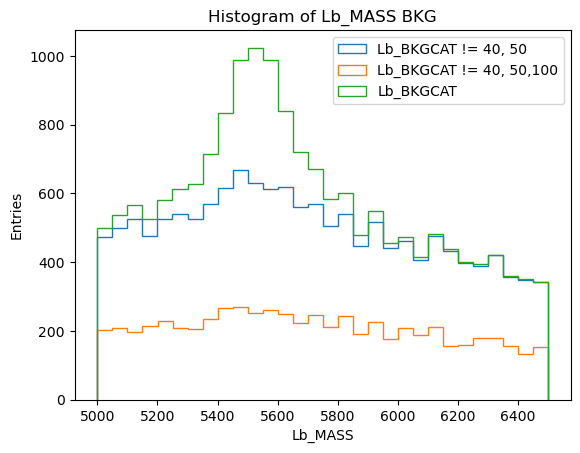

In [23]:
density = False
bins =30
caracteristica = 'Lb_MASS'


plt.hist(mc_background.query('(Lb_BKGCAT !=50) & (Lb_BKGCAT !=40)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT != 40, 50');
plt.hist(mc_background.query('(Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) & (Lb_BKGCAT != 100)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT != 40, 50,100');
plt.hist(mc_background['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT');
plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

Concluimos en eleiminarl el BKGCAt 40 y 50 que meten algo de señal

In [24]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(mc_background)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_background['prob1'] = signal_MVA_probs

[[9.99411719e-01 5.88280586e-04]
 [9.99370776e-01 6.29224165e-04]
 [8.90723772e-01 1.09276228e-01]
 ...
 [9.64073615e-01 3.59263846e-02]
 [9.99979170e-01 2.08296309e-05]
 [9.87317614e-01 1.26823856e-02]]


In [25]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Cargar el modelo entrenado
mlp = joblib.load('neural_network.pkl')

# Definir las claves neuronales
neural_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
               'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
               'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
               'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
               'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
               'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
               'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_MASS']

# Filtrar y preparar los datos
data24_selected_nan = mc_background.dropna()
data24_selected_nan_filtered = data24_selected_nan.query('(Lb_BKGCAT != 50) & (Lb_BKGCAT != 40)')

# Filtrar columnas que no están en neural_keys
data24_selected_filtered = data24_selected_nan_filtered[neural_keys]

# Escalar los datos
scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_filtered)

# Definir el umbral de máxima probabilidad
maxima_probabilidad = 0.99

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan_filtered.iloc[high_confidence_indices]

neural_data_mc_bkg_filtered = high_confidence_data

# Mostrar los datos filtrados
print(neural_data_mc_bkg_filtered)


            L_MASS      Lb_MASS    Jpsi_MASS         Jpsi_P       Jpsi_PT  \
0      1078.216064  5238.732910  3095.558350   48452.062500    915.653381   
3      1079.404053  5618.067383  3085.871338  137439.031250  11672.710938   
4      1079.486572  5058.527832  3089.232178  106942.375000   2282.969727   
70     1083.177490  5092.184570  3107.904785   88904.851562   7534.344727   
76     1083.282471  5113.281250  3088.973633   27526.472656   3639.113770   
78     1083.382080  5856.622070  3108.336914   28524.662109   1572.428345   
79     1083.391846  5829.304199  3089.886230   47790.113281   2292.231934   
106    1084.206787  5256.014160  2953.643555   67975.929688   2270.492920   
126    1084.910645  5105.195801  3104.037109   25254.720703    574.356567   
137    1085.181763  5389.849121  3103.584473   84727.062500   5557.007324   
142    1085.332275  5250.107422  3110.586182  150493.328125   3820.666748   
151    1085.506226  5159.092773  3098.490234   33019.250000   2798.677979   

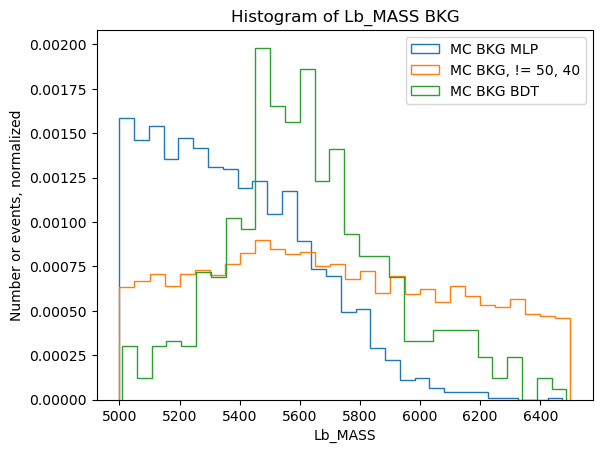

In [26]:

density = True
bins =30
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg_filtered['Lb_MASS'], bins=bins, histtype='step', label='MC BKG MLP', density= density);
plt.hist(mc_background.query('(Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) ')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG, != 50, 40');
plt.hist(mc_background.query('(prob1 > 0.99) & (Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) ')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

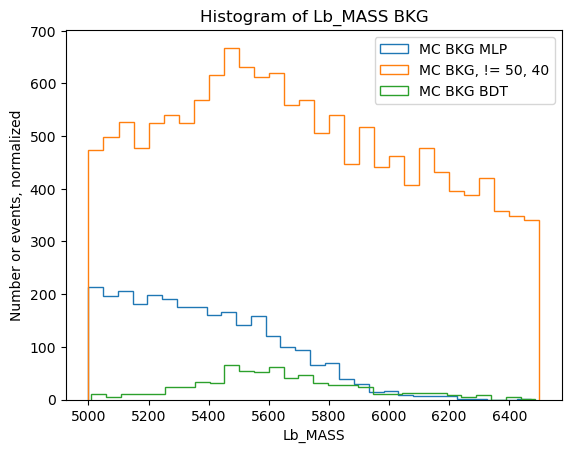

In [27]:

density = False
bins =30
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg_filtered['Lb_MASS'], bins=bins, histtype='step', label='MC BKG MLP', density= density);
plt.hist(mc_background.query('(Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) ')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG, != 50, 40');
plt.hist(mc_background.query('(prob1 > 0.99) & (Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) ')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

In [28]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Cargar el modelo entrenado
mlp = joblib.load('neural_network.pkl')

# Definir las claves neuronales
neural_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
               'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
               'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
               'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
               'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
               'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
               'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_MASS']

# Filtrar y preparar los datos
data24_selected_nan = mc_background.dropna()
data24_selected_nan_filtered = data24_selected_nan.query('(Lb_BKGCAT != 50) & (Lb_BKGCAT != 40) & (Lb_BKGCAT != 100)')

# Filtrar columnas que no están en neural_keys
data24_selected_filtered = data24_selected_nan_filtered[neural_keys]

# Escalar los datos
scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_filtered)

# Definir el umbral de máxima probabilidad
maxima_probabilidad = 0.99

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan_filtered.iloc[high_confidence_indices]

neural_data_mc_bkg_filtered = high_confidence_data

# Mostrar los datos filtrados
print(neural_data_mc_bkg_filtered)


            L_MASS      Lb_MASS    Jpsi_MASS         Jpsi_P       Jpsi_PT  \
0      1078.216064  5238.732910  3095.558350   48452.062500    915.653381   
3      1079.404053  5618.067383  3085.871338  137439.031250  11672.710938   
70     1083.177490  5092.184570  3107.904785   88904.851562   7534.344727   
79     1083.391846  5829.304199  3089.886230   47790.113281   2292.231934   
142    1085.332275  5250.107422  3110.586182  150493.328125   3820.666748   
151    1085.506226  5159.092773  3098.490234   33019.250000   2798.677979   
216    1086.926636  5234.600098  3086.687744   37170.800781   2336.061279   
301    1088.519775  5221.185547  3017.835937   33854.382812   1889.680298   
307    1088.646606  5604.542969  3083.647705   84198.890625   1772.974243   
374    1089.624878  5820.500488  3104.024902  172763.531250  10203.641602   
376    1089.649536  5716.787598  3100.435303   43168.964844   5557.020020   
393    1089.833008  5157.594238  3077.997559   91276.304688   6831.782715   

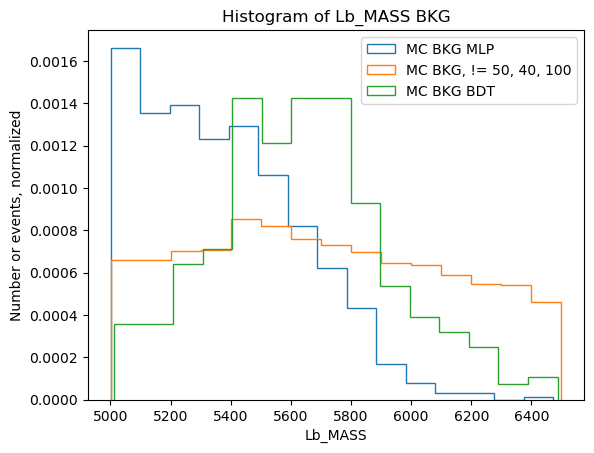

In [29]:

density = True
bins =15
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg_filtered['Lb_MASS'], bins=bins, histtype='step', label='MC BKG MLP', density= density);
plt.hist(mc_background.query('(Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) & (Lb_BKGCAT != 100) ')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG, != 50, 40, 100');
plt.hist(mc_background.query('(prob1 > 0.99) & (Lb_BKGCAT !=50) & (Lb_BKGCAT !=40)  & (Lb_BKGCAT != 100)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC BKG BDT');

plt.xlabel('Lb_MASS')
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

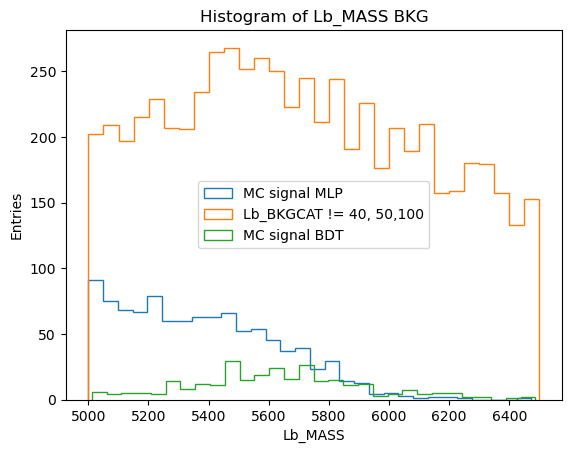

In [30]:

density = False
bins =30
caracteristica = 'Lb_MASS'

plt.hist(neural_data_mc_bkg_filtered['Lb_MASS'], bins=bins, histtype='step', label='MC signal MLP', density= density);
plt.hist(mc_background.query('(Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) & (Lb_BKGCAT != 100)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Lb_BKGCAT != 40, 50,100');
plt.hist(mc_background.query('(prob1 > 0.99) & (Lb_BKGCAT !=50) & (Lb_BKGCAT !=40) & (Lb_BKGCAT != 100)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal BDT');


plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS' + ' BKG')

plt.legend()

en esta sección vamos a comparar la BDT centrenada con las side bands y entrenada con todo el rando de los datos como fondo 

In [31]:
model = CatBoostClassifier().load_model("new_BDT_full_range")
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob_full_range'] = signal_MVA_probs

[[9.99263027e-01 7.36973010e-04]
 [9.99971192e-01 2.88080956e-05]
 [9.99986982e-01 1.30177972e-05]
 ...
 [9.99999997e-01 2.99106490e-09]
 [1.00000000e+00 5.58550328e-14]
 [9.99999354e-01 6.46121129e-07]]


In [32]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob'] = signal_MVA_probs

[[9.84703445e-01 1.52965554e-02]
 [9.94209527e-01 5.79047271e-03]
 [9.99287223e-01 7.12777302e-04]
 ...
 [9.99999960e-01 4.04437622e-08]
 [9.99999998e-01 2.28037468e-09]
 [9.99939766e-01 6.02339771e-05]]


In [33]:
# import joblib
# import pandas as pd
# from sklearn.preprocessing import StandardScaler

# # Cargar el modelo entrenado
# mlp = joblib.load('neural_network_full_range.pkl')

# # Definir las claves neuronales
# neural_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
#                'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
#                'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
#                'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
#                'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
#                'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
#                'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_MASS']

# # Filtrar y preparar los datos
# data24_selected_nan = signal_data.dropna()
# data24_selected_nan_filtered = data24_selected_nan

# # Filtrar columnas que no están en neural_keys
# data24_selected_filtered = data24_selected_nan_filtered[neural_keys]

# # Escalar los datos
# scaler = StandardScaler()
# data24_selected_nan_scaled = scaler.fit_transform(data24_selected_filtered)

# # Definir el umbral de máxima probabilidad
# maxima_probabilidad = 0.99

# # Predecir probabilidades en el nuevo conjunto de datos
# y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# # Filtrar los datos que  cumplan con la condición
# high_confidence_indices = y_pred > maxima_probabilidad
# high_confidence_data = data24_selected_nan_filtered.iloc[high_confidence_indices]

# neural_data_filtered = high_confidence_data

# # Mostrar los datos filtrados
# print(neural_data_filtered)


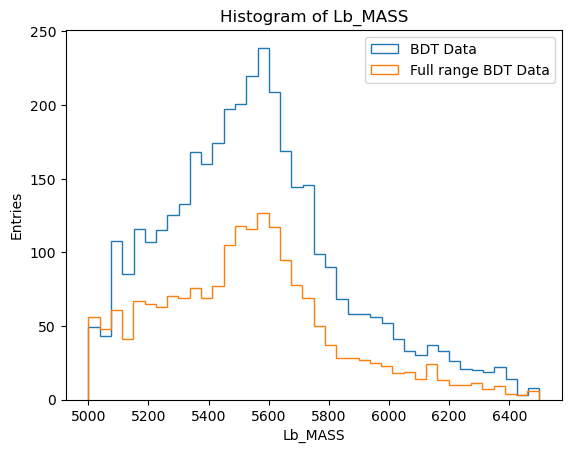

In [40]:
density = False
bins =40

# plt.hist(neural_data_filtered['Lb_MASS'], bins=bins, histtype='step', label='MLP Data', density= density);
plt.hist(signal_data.query('(prob > 0.98)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='BDT Data');
plt.hist(signal_data.query('(prob_full_range > 0.98)')['Lb_MASS'], bins=bins, density=density, histtype='step', label='Full range BDT Data');


plt.xlabel('Lb_MASS')
plt.ylabel('Entries')
plt.title('Histogram of '+ 'Lb_MASS')

plt.legend()